# Assignment 2: The "Smart Labeling Pipeline" Challenge

**Total Marks: 20**

Build a cost-effective, high-quality labeling pipeline using human annotation, programmatic rules, and LLMs.

This notebook implements an end-to-end smart labeling pipeline to:
1. Establish gold standard through human annotation and measure inter-annotator agreement (6 marks)
2. Label data programmatically using weak supervision (Snorkel) (6 marks)
3. Optimize labeling budget using active learning (5 marks)
4. Leverage LLMs for bulk labeling and detect hallucinations (e.g. noisy labels) (3 marks)

## Setup and Imports

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from snorkel.labeling import labeling_function, PandasLFApplier, LFAnalysis
from snorkel.labeling.model import LabelModel
from statsmodels.stats.inter_rater import fleiss_kappa
import google.generativeai as genai
import time
from pathlib import Path
import re

## Task 1: The Human as Annotator (6 Marks)

**Objective:** Establish a "Gold Standard" dataset and measure human consensus.

### Part 1.1: Parse Annotator CSV Files

After annotating the first 100 reviews, export annotations from three annotators (A, B, C) as CSV files.
Parse these CSV files into clean DataFrames for analysis.

![Label Studio Screenshot](label_studio.jpeg)

In [3]:
def parse_annotator_csv(csv_path, annotator_name):
    """
    Parses annotator CSV file into a clean DataFrame.

    Args:
        csv_path (str): Path to annotator CSV file

    Returns:
        pd.DataFrame: DataFrame with columns ['review_id', 'review', 'label']
                     where label is one of: 'Positive', 'Negative', 'Neutral'

    Note:
        - Look for relevant column names in the CSV file
        - If column names differ, the function will try to map them appropriately
        - Finally, return with two columns 'review' and 'label'
    """
    # TODO: Load CSV file using pd.read_csv()

    # TODO: Check and map column names if needed

    df = pd.read_csv(csv_path)

    # Identify and map review_id column
    review_id_cols = ['review_id', 'Review ID', 'Id', 'id']
    mapped_review_id_col = None
    for col in review_id_cols:
        if col in df.columns:
            df['review_id'] = df[col]
            mapped_review_id_col = col
            break
    if mapped_review_id_col is None:
        df['review_id'] = df.index

    # Identify and map review text column
    review_cols = ['review', 'text', 'Review Text', 'Review_Text']
    mapped_review_col = None
    for col in review_cols:
        if col in df.columns:
            df['review'] = df[col]
            mapped_review_col = col
            break
    if mapped_review_col is None:
        raise ValueError(f"Could not find a 'review' column in {csv_path}. Tried: {review_cols}")

    # Identify and map label column
    label_cols = [
        'label', 'sentiment', 'Annotation', 'Sentiment',
        'Annotator-1 (Srivibhav)',
        'Annotator-2 (Thushar)',
        'Annotator-3 (Bhavaram)'
    ]
    mapped_label_col = None
    for col in label_cols:
        if col in df.columns:
            df['label'] = df[col]
            mapped_label_col = col
            break
    if mapped_label_col is None:
        raise ValueError(f"Could not find a 'label' column in {csv_path}. Tried: {label_cols}")

    label_mapping = {
        'positive': 'Positive', 'pos': 'Positive', '+1': 'Positive',
        'negative': 'Negative', 'neg': 'Negative', '-1': 'Negative',
        'neutral': 'Neutral', 'neu': 'Neutral', '0': 'Neutral'
    }

    df['label'] = df['label'].astype(str).str.lower().map(label_mapping)

    if df['label'].isnull().any():
        unknown_labels = df[df['label'].isnull()][mapped_label_col].unique()
        print(f"Warning: Unmapped labels found in {csv_path}: {unknown_labels}. Defaulting to 'Neutral'.")
        df['label'] = df['label'].fillna('Neutral')

    df['annotator'] = annotator_name

    return df[['review_id', 'review', 'label', 'annotator']]

In [4]:
# TODO: Parse CSV files (replace with actual file paths)
df_a = parse_annotator_csv('annotator_a.csv', "Srivibhav")
df_b = parse_annotator_csv('annotator_b.csv', "Thushar")
df_c = parse_annotator_csv('annotator_c.csv', "Bhavaram")

# Display sample data
print("Annotator A DataFrame:")
print(df_a.head())
print("\nAnnotator B DataFrame:")
print(df_b.head())
print("\nAnnotator C DataFrame:")
print(df_c.head())

Annotator A DataFrame:
   review_id                                             review     label  \
0          0  This movie is a triumph in every sense. Highly...  Positive   
1          1  I have never been so bored in my life. The sco...  Negative   
2          2  I was completely blown away by this film. The ...  Positive   
3          3  The trailer was better than the movie. The act...  Negative   
4          4  Middle of the road entertainment. Visually it'...   Neutral   

   annotator  
0  Srivibhav  
1  Srivibhav  
2  Srivibhav  
3  Srivibhav  
4  Srivibhav  

Annotator B DataFrame:
   review_id                                             review     label  \
0          0  This movie is a triumph in every sense. Highly...  Positive   
1          1  I have never been so bored in my life. The sco...  Negative   
2          2  I was completely blown away by this film. The ...  Positive   
3          3  The trailer was better than the movie. The act...  Negative   
4          4  M

### Part 1.2: Implement Fleiss' Kappa from Scratch

Measure inter-annotator agreement using Fleiss' Kappa statistic.
Implement the formula from scratch and compare with statsmodels implementation.

In [5]:
def fleiss_kappa_scratch(rating_matrix):
    """
    Computes Fleiss' Kappa for multiple raters from scratch.

    Args:
        rating_matrix (np.array): A Count Matrix of shape (N, k).
                                  - N = number of items (rows)
                                  - k = number of categories (columns)
                                  - Element [i, j] = Count of raters who assigned category j to item i.
                                  Example:
                                    [[0, 0, 3],   # Item 0: All 3 raters said Category 2
                                     [1, 2, 0]]   # Item 1: 1 rater said Cat 0, 2 said Cat 1


    Returns:
        float: Kappa score (ranges from -1 to 1, where 1 = perfect agreement)

    Formula:
        κ = (P_bar - P_e_bar) / (1 - P_e_bar)

        where:
        - P_bar = (1/N) * Σ(P_i) = average proportion of agreement across all items
        - P_i = (1/(n*(n-1))) * Σ(k_ij * (k_ij - 1)) for item i
        - P_e_bar = Σ(p_j^2) = expected agreement by chance
        - p_j = proportion of all assignments to category j

    Note:
        - N = number of items (samples)
        - n = number of raters per item (should be constant)
        - k_ij = number of raters who assigned category j to item i
    """
    # TODO: Calculate P_bar (observed agreement), P_e_bar (expected agreement by chance), Apply the formula: κ = (P_bar - P_e_bar) / (1 - P_e_bar)
    N, k = rating_matrix.shape
    n = np.sum(rating_matrix[0])

    P_i = (1 / (n * (n - 1))) * np.sum(rating_matrix * (rating_matrix - 1), axis=1)
    P_bar = np.mean(P_i)

    p_j = np.sum(rating_matrix, axis=0) / (N * n)
    P_e_bar = np.sum(p_j ** 2)

    kappa = (P_bar - P_e_bar) / (1 - P_e_bar)
    return kappa

In [6]:
def prepare_rating_matrix(df_a, df_b, df_c):
    """
    Converts three DataFrames into a rating matrix for Fleiss' Kappa calculation.

    Args:
        df_a, df_b, df_c: DataFrames with columns ['review_id', 'review', 'label']

    Returns:
        np.array: Rating matrix of shape (N_samples, N_categories)
                  where categories are ['Negative', 'Neutral', 'Positive']
    """
    # TODO: Merge the three DataFrames on review
    # Hint: Use pd.merge() or pd.concat() with proper keys

    merged = df_a.merge(df_b, on='review_id', suffixes=('_a', '_b'))
    merged = merged.merge(df_c, on='review_id')
    merged.rename(columns={'label': 'label_c'}, inplace=True)

    # TODO: Return numpy array of shape (N_samples, 3)
    # Order: [Negative_count, Neutral_count, Positive_count] for each row

    categories = ['Negative', 'Neutral', 'Positive']
    rating_matrix = []

    for _, row in merged.iterrows():
        labels = [row['label_a'], row['label_b'], row['label_c']]
        counts = [
            labels.count('Negative'),
            labels.count('Neutral'),
            labels.count('Positive')
        ]
        rating_matrix.append(counts)

    return np.array(rating_matrix)


# TODO: Prepare rating matrix and calculate Fleiss' Kappa

rating_matrix = prepare_rating_matrix(df_a, df_b, df_c)
kappa_scratch = fleiss_kappa_scratch(rating_matrix)


# TODO: Use statsmodels to calculate Fleiss' Kappa

from statsmodels.stats.inter_rater import fleiss_kappa
kappa_statsmodels = fleiss_kappa(rating_matrix)


# TODO: Print the difference between the two implementations

print("Fleiss' Kappa (Scratch):", kappa_scratch)
print("Fleiss' Kappa (Statsmodels):", kappa_statsmodels)
print("Absolute Difference:", abs(kappa_scratch - kappa_statsmodels))

Fleiss' Kappa (Scratch): 0.6429888371157518
Fleiss' Kappa (Statsmodels): 0.6429888371157518
Absolute Difference: 0.0


### Part 1.3: Conflict Resolution

Identify conflicts where annotators disagree and resolve them using majority vote.
For complete ties (all three differ), default to 'Neutral'.

In [7]:
def resolve_conflicts(df_a, df_b, df_c):
    """
    Merges annotations from 3 annotators, resolves disagreements using Majority Vote,
    and handles complete ties by defaulting to 'Neutral'.

    Args:
        df_a, df_b, df_c: DataFrames from each annotator with columns ['review', 'label']

    Returns:
        pd.DataFrame: Final DataFrame with resolved labels (gold standard)
                     Columns: ['review', 'label']

    Logic:
        - Majority Vote: If 2 annotators agree, use their label
        - Tie-Breaker: If all 3 differ (e.g., Positive vs. Negative vs. Neutral), assign 'Neutral'
    """
    merged = df_a.merge(df_b, on='review_id', suffixes=('_a', '_b'))
    merged = merged.merge(df_c, on='review_id')
    merged.rename(columns={'label': 'label_c'}, inplace=True)

    final_labels = []

    for _, row in merged.iterrows():
        labels = [row['label_a'], row['label_b'], row['label_c']]
        counts = pd.Series(labels).value_counts()

        if counts.max() >= 2:
            final_labels.append(counts.idxmax())
        else:
            final_labels.append('Neutral')

    return pd.DataFrame({
        'review': merged['review_a'],
        'label': final_labels
    })

In [8]:
# TODO: Resolve conflicts and create gold standard

gold_df = resolve_conflicts(df_a, df_b, df_c)


# TODO: Display 5 examples of conflicting reviews (if <5 reviews, show all)
# Show what A, B, and C each said, and the final resolved label

merged_full = df_a.merge(df_b, on='review_id', suffixes=('_A', '_B'))
merged_full = merged_full.merge(df_c, on='review_id')
merged_full.rename(columns={'label': 'label_C'}, inplace=True)

conflicts = []

for _, row in merged_full.iterrows():
    labels = {row['label_A'], row['label_B'], row['label_C']}
    if len(labels) > 1:
        resolved_label = gold_df.loc[
            gold_df['review'] == row['review_A'], 'label'
        ].values[0]

        conflicts.append({
            "review": row['review_A'],
            "Annotator_A": row['label_A'],
            "Annotator_B": row['label_B'],
            "Annotator_C": row['label_C'],
            "Final_Label": resolved_label
        })

conflicts_df = pd.DataFrame(conflicts)
print(conflicts_df.head(5))


# TODO: Save gold standard to CSV

gold_df.to_csv("gold_standard.csv", index=False)

                                              review Annotator_A Annotator_B  \
0  It tries to be deep, but comes off as dull des...     Neutral     Neutral   
1  I am confused about how I feel. It left me puz...     Neutral    Positive   
2  The direction was typical, but nothing special...    Negative     Neutral   
3  I tried to like it, I really did, but it faile...    Negative     Neutral   
4  I am confused about how I feel. Your mileage m...     Neutral    Positive   

  Annotator_C Final_Label  
0    Negative     Neutral  
1     Neutral     Neutral  
2     Neutral     Neutral  
3    Negative    Negative  
4     Neutral     Neutral  


## Task 2: Weak Supervision (The "Lazy" Labeler) (6 Marks)

**Objective:** Label the next 200 reviews programmatically to save time.

### Part 2.1: Heuristic Development

Analyze patterns in the gold standard and write at least 3 heuristic functions.
Apply them to the remaining 200 unlabeled reviews.

In [13]:
# Constants for labeling functions
POSITIVE = 1
NEGATIVE = 0
NEUTRAL = 2
ABSTAIN = -1

# TODO: Load gold standard to analyze patterns
gold_df = pd.read_csv('gold_standard_100.csv')
print(f"Gold Standard shape: {gold_df.shape}")
print(f"\nLabel distribution:\n{gold_df['label'].value_counts()}")

# TODO: Analyze patterns (e.g., common positive/negative words, review length, etc.)
# This will help you design effective heuristics
print("\n--- Sample Positive Reviews ---")
for r in gold_df[gold_df['label'] == 'Positive']['review'].head(5).values:
    print(f"  • {r[:120]}")

print("\n--- Sample Negative Reviews ---")
for r in gold_df[gold_df['label'] == 'Negative']['review'].head(5).values:
    print(f"  • {r[:120]}")

print("\n--- Sample Neutral Reviews ---")
for r in gold_df[gold_df['label'] == 'Neutral']['review'].head(5).values:
    print(f"  • {r[:120]}")

# Analyze common words per class
from collections import Counter
for label in ['Positive', 'Negative', 'Neutral']:
    words = ' '.join(gold_df[gold_df['label'] == label]['review'].str.lower()).split()
    common = Counter(words).most_common(15)
    print(f"\nTop words in {label}: {[w for w, c in common]}")

Gold Standard shape: (100, 2)

Label distribution:
label
Neutral     45
Positive    30
Negative    25
Name: count, dtype: int64

--- Sample Positive Reviews ---
  • This movie is a triumph in every sense. Highly recommended for everyone.
  • I was completely blown away by this film. The lead actor delivered a refreshing performance. I will be thinking about th
  • It perfectly balances humor and drama. I was hooked from the very first minute.
  • Simply put, this is cinema at its finest. The chemistry between the cast was superb. Don't miss this one.
  • Wow, just wow. Every scene felt earned, and the costume design was masterful. Two thumbs way up.

--- Sample Negative Reviews ---
  • I have never been so bored in my life. The score was frankly cringe-worthy. Avoid this at all costs.
  • The trailer was better than the movie. The acting was frankly tedious. A complete misfire.
  • I have never been so bored in my life. Nothing about the opening scene worked. A complete misfire.
  • No

### Part 2.2: Snorkel Labeling Functions

Wrap your heuristics as Snorkel @labeling_function decorators.
Each function should return POSITIVE (1), NEGATIVE (0), NEUTRAL (2), or ABSTAIN (-1).

In [14]:
@labeling_function()
def lf_keyword_great(x):
    """
    Example labeling function: Check if "great" appears in the review.
    Returns POSITIVE if found, otherwise ABSTAIN.
    """
    # TODO: Check if "great" (case-insensitive) is in x.review
    # Return POSITIVE if found, ABSTAIN otherwise
    text = x.review.lower()
    if 'great' in text:
        # "great" sometimes appears in negative context like "should have been great, but"
        if 'should have been great' in text or 'but' in text.split('great')[1][:20] if 'great' in text else False:
            return ABSTAIN
        return POSITIVE
    return ABSTAIN

@labeling_function()
def lf_short_review(x):
    """
    Label based on review length.
    Very short reviews might be neutral or indicate lack of engagement.
    """
    # TODO: Implement logic based on review length
    # Return appropriate label (NEUTRAL for very short, or ABSTAIN)
    if len(x.review.split()) <= 12:
        return NEUTRAL
    return ABSTAIN

@labeling_function()
def lf_regex_bad(x):
    """
    Use regex to find negative patterns.
    Look for words like "horrible", "terrible", "awful", etc.
    """
    # TODO: Use regex or string matching to find negative keywords
    # Return NEGATIVE if found, ABSTAIN otherwise
    pattern = r'\b(horrible|terrible|awful|garbage|worst|boring|waste|disappointing|train wreck|misfire)\b'
    if re.search(pattern, x.review.lower()):
        return NEGATIVE
    return ABSTAIN

# TODO: Write at least 3 more labeling functions (minimum 6 total)

@labeling_function()
def lf_strong_positive_keywords(x):
    """
    Detect strong positive sentiment keywords commonly found in positive reviews.
    """
    text = x.review.lower()
    positive_words = [
        'masterpiece', 'triumph', 'superb', 'brilliant', 'phenomenal',
        'blown away', 'must-watch', 'must watch', 'joy to watch',
        'two thumbs', 'finest', 'highly recommended', 'don\'t miss',
        'do yourself a favor', 'can\'t wait to see it again',
        'deserves all the awards', 'cinema at its finest',
        'absolute joy', 'hooked from'
    ]
    for word in positive_words:
        if word in text:
            return POSITIVE
    return ABSTAIN

@labeling_function()
def lf_strong_negative_keywords(x):
    """
    Detect strong negative sentiment keywords commonly found in negative reviews.
    """
    text = x.review.lower()
    negative_words = [
        'total garbage', 'zero stars', 'walked out', 'hard pass',
        'want my two hours back', 'worst enemy', 'save your money',
        'never been so bored', 'complete waste', 'utterly disappointing',
        'train wreck', 'do not bother', 'wouldn\'t recommend',
        'struggled to sit', 'couldn\'t get past'
    ]
    for word in negative_words:
        if word in text:
            return NEGATIVE
    return ABSTAIN

@labeling_function()
def lf_neutral_hedging(x):
    """
    Detect neutral/ambivalent language - hedging phrases that signal mixed feelings.
    """
    text = x.review.lower()
    neutral_phrases = [
        'mixed feelings', 'middle of the road', 'it is what it is',
        'neither good nor bad', 'it was... fine', 'it was fine',
        'not a masterpiece, but', 'confused about how i feel',
        'difficult movie to categorize', 'standard fare',
        'popcorn filler', 'good for a one-time watch',
        'acceptable, but forgettable', 'won\'t remember it',
        'doesn\'t leave a lasting impression', 'low expectations and they were met',
        'just exists', 'serves its purpose'
    ]
    for phrase in neutral_phrases:
        if phrase in text:
            return NEUTRAL
    return ABSTAIN

@labeling_function()
def lf_exclamation_positive(x):
    """
    Reviews with 'wow' or strong exclamatory positive phrases tend to be positive.
    """
    text = x.review.lower()
    if 'wow' in text or 'just wow' in text:
        return POSITIVE
    return ABSTAIN

@labeling_function()
def lf_oscillated_mixed(x):
    """
    Reviews mentioning oscillation between feelings, or 'weird mix' are often neutral.
    """
    text = x.review.lower()
    if 'oscillated between' in text or 'weird mix' in text or 'polarizing' in text:
        return NEUTRAL
    return ABSTAIN

@labeling_function()
def lf_refreshing_positive(x):
    """
    Reviews with 'refreshing take' or 'balances humor and drama' are positive.
    """
    text = x.review.lower()
    if 'refreshing take' in text or 'balances humor and drama' in text or 'cinematic masterpiece' in text:
        return POSITIVE
    return ABSTAIN

@labeling_function()
def lf_avoid_negative(x):
    """
    Reviews containing 'avoid' or 'do not bother' are strongly negative.
    """
    text = x.review.lower()
    if 'avoid this' in text or 'do not bother' in text or 'frustrating experience' in text:
        return NEGATIVE
    return ABSTAIN

print("All labeling functions defined successfully.")

All labeling functions defined successfully.


### Part 2.3: Apply Labeling Functions and Analyze Coverage

Apply all labeling functions to the 200 unlabeled reviews and calculate coverage and conflict rates.

In [15]:
def analyze_weak_labels(L_matrix, lfs):
    """
    Prints Coverage and Conflict statistics for the Labeling Functions.

    Args:
        L_matrix (np.array): Label matrix of shape (N_samples, N_functions)
                            Each column represents one labeling function's outputs
                            Values: POSITIVE (1), NEGATIVE (0), NEUTRAL (2), ABSTAIN (-1)
        lfs: List of labeling functions (for display names)

    Metrics to calculate:
        - Coverage: Percentage of non-abstain votes per LF
        - Conflict Rate: Percentage of samples where LFs disagree
    """
    # TODO: Calculate coverage for each labeling function
    # Coverage = (number of non-abstain votes) / (total samples) * 100
    n_samples = L_matrix.shape[0]

    print(f"{'LF Name':<35} {'Coverage %':<15} {'Non-Abstain Count'}")
    print("-" * 70)
    for i, lf in enumerate(lfs):
        non_abstain = np.sum(L_matrix[:, i] != ABSTAIN)
        coverage = non_abstain / n_samples * 100
        print(f"{lf.name:<35} {coverage:<15.1f} {non_abstain}")

    # TODO: Calculate conflict rate
    # Conflict occurs when multiple LFs label the same sample differently
    # Conflict Rate = (number of conflicting samples) / (total samples) * 100
    conflict_count = 0
    for row in L_matrix:
        non_abstain_labels = row[row != ABSTAIN]
        if len(non_abstain_labels) > 1 and len(set(non_abstain_labels)) > 1:
            conflict_count += 1

    conflict_rate = conflict_count / n_samples * 100

    # TODO: Print statistics in a readable format
    # Hint: Use LFAnalysis from snorkel for detailed stats (optional)
    # Or print manually: LF name, Coverage %, Conflicts count
    print(f"\nOverall Conflict Rate: {conflict_rate:.1f}% ({conflict_count}/{n_samples} samples)")

    # Overall coverage: % of samples with at least one non-abstain vote
    any_label = np.sum(np.any(L_matrix != ABSTAIN, axis=1))
    print(f"Overall Coverage: {any_label / n_samples * 100:.1f}% ({any_label}/{n_samples} samples)")

# TODO: Load the 200 unlabeled reviews (you can load the entire dataset and then filter as per the requirement)
all_reviews = pd.read_csv('movie_reviews_300.csv')
# First 100 are the gold standard, next 200 are unlabeled
unlabeled_200 = all_reviews.iloc[100:300].reset_index(drop=True)
print(f"Loaded {len(unlabeled_200)} unlabeled reviews for weak supervision.\n")

# TODO: Apply all labeling functions to create L_matrix
# lfs = [lf_keyword_great, lf_short_review, lf_regex_bad, ...]  # Add all your LFs
lfs = [
    lf_keyword_great, lf_short_review, lf_regex_bad,
    lf_strong_positive_keywords, lf_strong_negative_keywords,
    lf_neutral_hedging, lf_exclamation_positive, lf_oscillated_mixed,
    lf_refreshing_positive, lf_avoid_negative
]
# applier = <put your code here>
applier = PandasLFApplier(lfs=lfs)
# L_matrix = <put your code here>
L_matrix = applier.apply(df=unlabeled_200)

# TODO: Analyze coverage and conflicts
print("=" * 70)
print("LABELING FUNCTION ANALYSIS")
print("=" * 70)
analyze_weak_labels(L_matrix, lfs)

# TODO: Use LFAnalysis for detailed statistics
print("\n--- Snorkel LFAnalysis Summary ---")
lf_analysis = LFAnalysis(L=L_matrix, lfs=lfs)
print(lf_analysis.lf_summary())

Loaded 200 unlabeled reviews for weak supervision.



100%|██████████| 200/200 [00:00<00:00, 14626.79it/s]

LABELING FUNCTION ANALYSIS
LF Name                             Coverage %      Non-Abstain Count
----------------------------------------------------------------------
lf_keyword_great                    0.0             0
lf_short_review                     16.0            32
lf_regex_bad                        15.0            30
lf_strong_positive_keywords         25.5            51
lf_strong_negative_keywords         20.5            41
lf_neutral_hedging                  29.0            58
lf_exclamation_positive             3.0             6
lf_oscillated_mixed                 9.5             19
lf_refreshing_positive              6.5             13
lf_avoid_negative                   5.5             11

Overall Conflict Rate: 16.5% (33/200 samples)
Overall Coverage: 84.5% (169/200 samples)

--- Snorkel LFAnalysis Summary ---
                             j Polarity  Coverage  Overlaps  Conflicts
lf_keyword_great             0       []     0.000     0.000      0.000
lf_short_review  

### Part 2.4: Majority Vote Adjudication

Use majority vote to generate probabilistic labels (weak labels) for the 200 reviews.
Save the result to `weak_labels_200.csv`.

In [16]:
# TODO: Train LabelModel to get probabilistic labels
label_model = LabelModel(cardinality=3, verbose=True)
label_model.fit(L_train=L_matrix, n_epochs=500, log_freq=100, seed=42)

# Predict labels using the trained LabelModel
predicted_labels = label_model.predict(L=L_matrix)

# TODO: Convert numeric labels to match your label scheme
# Label mapping: 0 -> 'Negative' (or 0), 1 -> 'Positive' (or 1), 2 -> 'Neutral' (or 2), -1 -> 'Abstain'
label_name_map = {0: 'Negative', 1: 'Positive', 2: 'Neutral', -1: 'Abstain'}
predicted_label_names = [label_name_map.get(l, 'Abstain') for l in predicted_labels]

# TODO: Create DataFrame with reviews and weak labels
weak_labels_df = pd.DataFrame({
    'review': unlabeled_200['review'].values,
    'weak_label': predicted_labels,
    'weak_label_name': predicted_label_names
})

# Print label distribution
print("\nWeak Label Distribution:")
print(weak_labels_df['weak_label_name'].value_counts())

abstain_count = (weak_labels_df['weak_label'] == -1).sum()
print(f"\nAbstain count: {abstain_count} / {len(weak_labels_df)} ({abstain_count/len(weak_labels_df)*100:.1f}%)")
print(f"Labeled count: {len(weak_labels_df) - abstain_count} / {len(weak_labels_df)} ({(len(weak_labels_df)-abstain_count)/len(weak_labels_df)*100:.1f}%)")

# TODO: Save to CSV
weak_labels_df.to_csv('weak_labels_200.csv', index=False)
print("\nSaved weak_labels_200.csv")

INFO:root:Computing O...
INFO:root:Estimating \mu...
 14%|█▍        | 72/500 [00:00<00:00, 716.77epoch/s]INFO:root:[100 epochs]: TRAIN:[loss=0.014]
INFO:root:[200 epochs]: TRAIN:[loss=0.005]
 52%|█████▏    | 259/500 [00:00<00:00, 1334.61epoch/s]INFO:root:[300 epochs]: TRAIN:[loss=0.003]
INFO:root:[400 epochs]: TRAIN:[loss=0.003]
100%|██████████| 500/500 [00:00<00:00, 1424.61epoch/s]
INFO:root:Finished Training



Weak Label Distribution:
weak_label_name
Neutral     64
Positive    54
Negative    51
Abstain     31
Name: count, dtype: int64

Abstain count: 31 / 200 (15.5%)
Labeled count: 169 / 200 (84.5%)

Saved weak_labels_200.csv


## Task 3: Active Learning (The Budget Optimizer) (5 Marks)

**Objective:** Simulate cost savings by training a model iteratively.

### Part 3.1: Query Strategy Implementation

Implement Least Confidence and Entropy Sampling from scratch.
These strategies select the most informative samples for labeling.

In [17]:
def least_confidence_sampling(model, X_pool, n_instances=10):
    """
    Selects samples where the model is least confident (uncertainty sampling).

    Args:
        model: Trained classifier with predict_proba() method
        X_pool: Feature matrix of unlabeled samples
        n_instances: Number of samples to select

    Returns:
        np.array: Indices of selected samples

    Strategy:
        Uncertainty = 1 - max(probability) across all classes
        For 3-class classification: Get probabilities for [Negative, Positive, Neutral]
        Select samples with highest uncertainty (lowest max probability)
    """
    # TODO: Get probability predictions from model
    probs = model.predict_proba(X_pool)

    # TODO: Calculate uncertainty: 1 - max(probability) for each sample
    uncertainty = 1 - np.max(probs, axis=1)

    # TODO: Select top n_instances samples with highest uncertainty
    query_indices = np.argsort(uncertainty)[-n_instances:]
    return query_indices

def entropy_sampling(model, X_pool, n_instances=10):
    """
    Selects samples with highest entropy (information gain).

    Args:
        model: Trained classifier with predict_proba() method
        X_pool: Feature matrix of unlabeled samples
        n_instances: Number of samples to select

    Returns:
        np.array: Indices of selected samples

    Strategy:
        Entropy = -sum(p * log(p)) for all classes
        For 3-class classification: Calculate entropy across [Negative, Positive, Neutral] probabilities
        Select samples with highest entropy (most uncertain across all classes)
    """
    # TODO: Get probability predictions from model
    probs = model.predict_proba(X_pool)

    # TODO: Calculate entropy: -sum(p * log(p)) for each sample
    # Add small epsilon (1e-9) to avoid log(0) errors
    epsilon = 1e-9
    entropy = -np.sum(probs * np.log(probs + epsilon), axis=1)

    # TODO: Select top n_instances samples with highest entropy
    query_indices = np.argsort(entropy)[-n_instances:]
    return query_indices

def random_sampling(model, X_pool, n_instances=10):
    """
    Baseline strategy: Selects random samples.

    Args:
        model: Not used, but kept for interface consistency
        X_pool: Feature matrix of unlabeled samples
        n_instances: Number of samples to select

    Returns:
        np.array: Randomly selected indices
    """
    # TODO: Randomly select n_instances indices from X_pool
    n_instances = min(n_instances, len(X_pool))
    query_indices = np.random.choice(len(X_pool), size=n_instances, replace=False)
    return query_indices

### Part 3.2: Data Processing and Setup

Load the gold standard (seed) and weak labels (pool).
Create a static test set from the pool for evaluation.
Vectorize text data using TF-IDF.

In [21]:
def load_and_process_data():
    """
    Loads and processes data for active learning.

    Returns:
        Tuple: (X_seed, y_seed, X_pool, y_pool, X_test, y_test, vectorizer)
               All X are feature matrices, all y are label arrays
               vectorizer is returned for later use on LLM data

    Note:
        - Seed: gold_standard_100.csv (100 labeled reviews)
        - Pool: weak_labels_200.csv (200 reviews, labels treated as hidden for simulation)
        - Test: Hold out 50 samples from pool (weak labels) for static evaluation
        - We use 3-class classification: Positive (1), Negative (0), Neutral (2)
        - Uncertainty metrics use probability scores across all three classes:
          * Least Confidence: 1 - max(probabilities) across all classes
          * Entropy: -sum(p * log(p)) for all three classes
    """

    df_seed = pd.read_csv('gold_standard_100.csv')
    df_pool_full = pd.read_csv('weak_labels_200.csv')

    # Ensure both have 'review' column
    if 'review' not in df_seed.columns:
        raise ValueError("gold_standard_100.csv must have 'review' column")
    if 'review' not in df_pool_full.columns:
        raise ValueError("weak_labels_200.csv must have 'review' column")

    # Handle both 'label' and 'sentiment' column names
    label_col_seed = 'label' if 'label' in df_seed.columns else 'sentiment'

    # Handle weak_labels_200.csv column naming
    # The file may have 'weak_label' (numeric) and 'weak_label_name' columns
    if 'weak_label' in df_pool_full.columns:
        label_col_pool = 'weak_label'
    elif 'label' in df_pool_full.columns:
        label_col_pool = 'label'
    else:
        label_col_pool = 'sentiment'

    # Map text labels to numeric: Positive=1, Negative=0, Neutral=2
    label_mapping = {
        'Positive': 1, 'positive': 1, 'POSITIVE': 1,
        'Negative': 0, 'negative': 0, 'NEGATIVE': 0,
        'Neutral': 2, 'neutral': 2, 'NEUTRAL': 2
    }

    # Convert seed labels
    if df_seed[label_col_seed].dtype == 'object':
        df_seed['sentiment_numeric'] = df_seed[label_col_seed].map(label_mapping)
        if df_seed['sentiment_numeric'].isna().any():
            raise ValueError(f"Unknown labels in seed data: {df_seed[df_seed['sentiment_numeric'].isna()][label_col_seed].unique()}")
    else:
        df_seed['sentiment_numeric'] = df_seed[label_col_seed].values

    # Convert pool labels
    if df_pool_full[label_col_pool].dtype == 'object':
        df_pool_full['sentiment_numeric'] = df_pool_full[label_col_pool].map(label_mapping)
        if df_pool_full['sentiment_numeric'].isna().any():
            raise ValueError(f"Unknown labels in pool data: {df_pool_full[df_pool_full['sentiment_numeric'].isna()][label_col_pool].unique()}")
    else:
        # Already numeric (0=Negative, 1=Positive, 2=Neutral, -1=Abstain)
        df_pool_full['sentiment_numeric'] = df_pool_full[label_col_pool].values

    # Filter out Abstain rows (-1) from pool — they have no usable label
    abstain_count = (df_pool_full['sentiment_numeric'] == -1).sum()
    if abstain_count > 0:
        print(f"Filtering out {abstain_count} Abstain rows from pool data.")
        df_pool_full = df_pool_full[df_pool_full['sentiment_numeric'] != -1].reset_index(drop=True)

    print(f"Pool data after filtering: {len(df_pool_full)} reviews")

    # Create static test set (hold out 50 samples from pool)
    df_pool, df_test = train_test_split(df_pool_full, test_size=50, random_state=42)

    # Vectorize text data using TfidfVectorizer
    # Fit vectorizer on ALL text (seed + pool + test) to ensure consistent dimensions
    vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
    all_text = pd.concat([df_seed['review'], df_pool['review'], df_test['review']])
    vectorizer.fit(all_text)

    # Transform datasets to feature matrices
    X_seed = vectorizer.transform(df_seed['review']).toarray()
    X_pool = vectorizer.transform(df_pool['review']).toarray()
    X_test = vectorizer.transform(df_test['review']).toarray()

    # Extract numeric labels
    y_seed = df_seed['sentiment_numeric'].values.astype(int)
    y_pool = df_pool['sentiment_numeric'].values.astype(int)
    y_test = df_test['sentiment_numeric'].values.astype(int)

    # Return all datasets and vectorizer
    return X_seed, y_seed, X_pool, y_pool, X_test, y_test, vectorizer

# TODO: uncomment below codes, to use these variables further
X_seed, y_seed, X_pool, y_pool, X_test, y_test, vectorizer = load_and_process_data()

print(f"Seed Size: {len(y_seed)}")
print(f"Pool Size: {len(y_pool)} (Available for querying)")
print(f"Test Size: {len(y_test)} (Held out for evaluation)")

Filtering out 31 Abstain rows from pool data.
Pool data after filtering: 169 reviews
Seed Size: 100
Pool Size: 119 (Available for querying)
Test Size: 50 (Held out for evaluation)


### Part 3.3: Active Learning Loop

Implement the iterative active learning loop:
1. Train model on current training set
2. Query uncertain samples from pool
3. "Label" them (reveal ground truth)
4. Add to training set and retrain
5. Log test accuracy

In [26]:
def run_active_learning_loop(X_seed, y_seed, X_pool, y_pool, X_test, y_test,
                             strategy_func, steps=5, batch_size=10):
    """
    Simulates the active learning loop (matches lab approach).

    Args:
        X_seed, y_seed: Initial training data (seed set)
        X_pool, y_pool: Unlabeled pool (y_pool is hidden, revealed during query)
        X_test, y_test: Static test set for evaluation
        strategy_func: Function that selects samples (e.g., least_confidence_sampling)
                      Signature: strategy_func(model, X_pool, n_instances) -> indices
        steps: Number of iterations
        batch_size: Number of samples to query per iteration

    Returns:
        Tuple: (n_labels_history, accuracy_history)
               Lists tracking number of labels and test accuracy over iterations
    """
    # TODO: Initialize training set with seed data
    X_train = X_seed.copy()
    y_train = y_seed.copy()

    # TODO: Create working copies of pool (we'll remove samples as we query them)
    X_pool_curr = X_pool.copy()
    y_pool_curr = y_pool.copy()

    # TODO: Initialize empty lists to track progress (accuracy_history, n_labels_history)
    accuracy_history = []
    n_labels_history = []

    # Train initial model on seed data
    model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
    model.fit(X_train, y_train)

    # TODO: Evaluate initial model and log results
    initial_acc = accuracy_score(y_test, model.predict(X_test))
    accuracy_history.append(initial_acc)
    n_labels_history.append(len(y_train))
    print(f"Initial — Training size: {len(y_train)}, Test Accuracy: {initial_acc:.4f}")

    # TODO: Iterative loop (repeat 'steps' times):
    #   for i in range(steps):
    #       1. Query: Use strategy_func(model, X_pool_curr, batch_size) to get indices
    #       2. "Label": Reveal ground truth: y_new = y_pool_curr[query_indices]
    #       3. Add to training set: use np.vstack() to add new samples
    #       4. Remove from pool: use np.delete() to remove queried samples
    #       5. Retrain model: use model.fit() to update the model
    #       6. Evaluate on test set, get accuracy
    #       7. Log: accuracy_history.append(acc), n_labels_history.append(len(y_train))
    for i in range(steps):
        if len(X_pool_curr) == 0:
            print(f"Step {i+1}: Pool is empty, stopping early.")
            break

        # 1. Query: Use strategy_func to get indices of uncertain samples
        query_indices = strategy_func(model, X_pool_curr, n_instances=batch_size)

        # 2. "Label": Reveal ground truth
        X_new = X_pool_curr[query_indices]
        y_new = y_pool_curr[query_indices]

        # 3. Add to training set
        X_train = np.vstack([X_train, X_new])
        y_train = np.concatenate([y_train, y_new])

        # 4. Remove from pool
        X_pool_curr = np.delete(X_pool_curr, query_indices, axis=0)
        y_pool_curr = np.delete(y_pool_curr, query_indices, axis=0)

        # 5. Retrain model
        model.fit(X_train, y_train)

        # 6. Evaluate on test set
        acc = accuracy_score(y_test, model.predict(X_test))

        # 7. Log results
        accuracy_history.append(acc)
        n_labels_history.append(len(y_train))
        print(f"Step {i+1} — Training size: {len(y_train)}, Test Accuracy: {acc:.4f}")

    # TODO: Return history lists
    return n_labels_history, accuracy_history

# TODO: Run active learning with least confidence strategy
print("=" * 60)
print("Running Active Learning with Least Confidence Sampling...")
print("=" * 60)
n_labels_lc, acc_lc = run_active_learning_loop(
    X_seed, y_seed, X_pool, y_pool, X_test, y_test,
    strategy_func=least_confidence_sampling, steps=5, batch_size=10
)

print("\n" + "=" * 60)
print("Running Active Learning with Entropy Sampling...")
print("=" * 60)
n_labels_ent, acc_ent = run_active_learning_loop(
    X_seed, y_seed, X_pool, y_pool, X_test, y_test,
    strategy_func=entropy_sampling, steps=5, batch_size=10
)

Running Active Learning with Least Confidence Sampling...
Initial — Training size: 100, Test Accuracy: 0.8200
Step 1 — Training size: 110, Test Accuracy: 0.9000
Step 2 — Training size: 120, Test Accuracy: 0.9000
Step 3 — Training size: 130, Test Accuracy: 0.9600
Step 4 — Training size: 140, Test Accuracy: 0.9600
Step 5 — Training size: 150, Test Accuracy: 0.9600

Running Active Learning with Entropy Sampling...
Initial — Training size: 100, Test Accuracy: 0.8200
Step 1 — Training size: 110, Test Accuracy: 0.9000
Step 2 — Training size: 120, Test Accuracy: 0.9000
Step 3 — Training size: 130, Test Accuracy: 0.9600
Step 4 — Training size: 140, Test Accuracy: 0.9600
Step 5 — Training size: 150, Test Accuracy: 0.9600


c:\Users\sriva\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\sriva\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\sriva\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\sriva\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in versio

### Part 3.4: Visualization and Comparison

Plot learning curves comparing Active Learning vs. Random Sampling.

Running Active Learning with Random Sampling (Baseline)...
Initial — Training size: 100, Test Accuracy: 0.8200
Step 1 — Training size: 110, Test Accuracy: 0.8200
Step 2 — Training size: 120, Test Accuracy: 0.8400
Step 3 — Training size: 130, Test Accuracy: 0.8400
Step 4 — Training size: 140, Test Accuracy: 0.8600
Step 5 — Training size: 150, Test Accuracy: 0.9200


c:\Users\sriva\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\sriva\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\sriva\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\sriva\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in versio

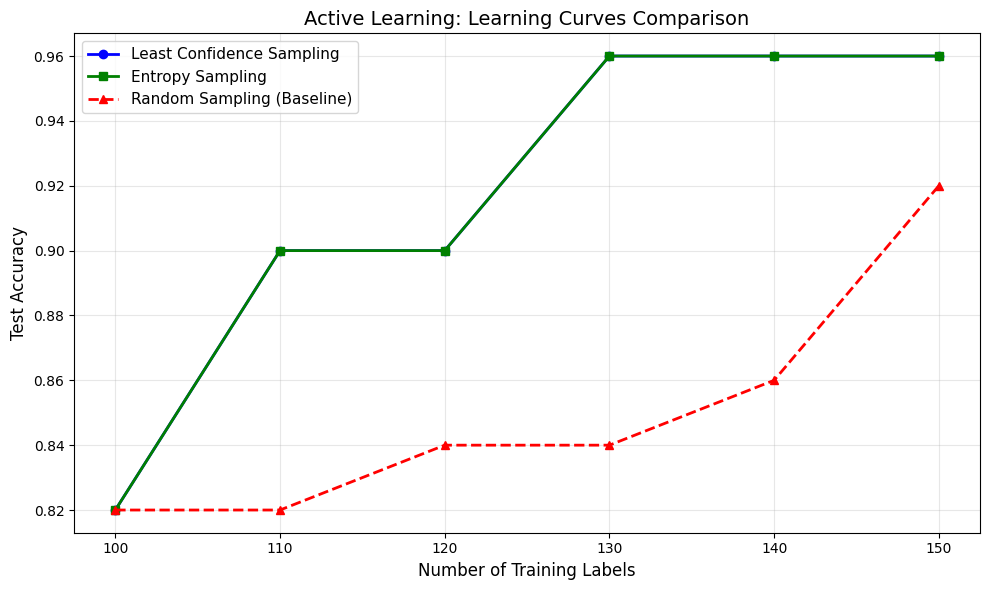


COMPARISON SUMMARY
Strategy                       Final Accuracy       Final Training Size
----------------------------------------------------------------------
Least Confidence               0.9600               150
Entropy Sampling               0.9600               150
Random Sampling                0.9200               150
----------------------------------------------------------------------

✅ Least Confidence outperforms Random by 0.0400 accuracy points!


In [28]:
# TODO: Run active learning with random sampling (baseline)
print("=" * 60)
print("Running Active Learning with Random Sampling (Baseline)...")
print("=" * 60)
n_labels_rand, acc_rand = run_active_learning_loop(
    X_seed, y_seed, X_pool, y_pool, X_test, y_test,
    strategy_func=random_sampling, steps=5, batch_size=10
)

# TODO: Plot learning curves of active learning and random sampling wrt to number of samples
plt.figure(figsize=(10, 6))
plt.plot(n_labels_lc, acc_lc, 'b-o', label='Least Confidence Sampling', linewidth=2)
plt.plot(n_labels_ent, acc_ent, 'g-s', label='Entropy Sampling', linewidth=2)
plt.plot(n_labels_rand, acc_rand, 'r--^', label='Random Sampling (Baseline)', linewidth=2)
plt.xlabel('Number of Training Labels', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Active Learning: Learning Curves Comparison', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# TODO: Print comparison summary for active learning and random sampling final accuracy
print("\n" + "=" * 60)
print("COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Strategy':<30} {'Final Accuracy':<20} {'Final Training Size'}")
print("-" * 70)
print(f"{'Least Confidence':<30} {acc_lc[-1]:<20.4f} {n_labels_lc[-1]}")
print(f"{'Entropy Sampling':<30} {acc_ent[-1]:<20.4f} {n_labels_ent[-1]}")
print(f"{'Random Sampling':<30} {acc_rand[-1]:<20.4f} {n_labels_rand[-1]}")
print("-" * 70)

# Highlight savings
best_active = max(acc_lc[-1], acc_ent[-1])
best_name = "Least Confidence" if acc_lc[-1] >= acc_ent[-1] else "Entropy"
diff = best_active - acc_rand[-1]
if diff > 0:
    print(f"\n✅ {best_name} outperforms Random by {diff:.4f} accuracy points!")
else:
    print(f"\n⚠ Random sampling performed comparably or better in this run.")

## Task 4: AI vs. AI (LLM & Noise Detection) (3 Marks)

**Objective:** Use LLMs for bulk labeling and detect hallucinations.

**Note:**

- Make an account at [open-router](https://openrouter.ai/) and get the API key.
- Use `google/gemini-2.5-flash-lite` (free tier) model as your LLM. Read the documentation on how to use it [here](https://openrouter.ai/google/gemini-2.5-flash-lite/api)
- Set environment variable using .env file and paste your API key in it.

### Part 4.1: LLM Pipeline with Few-Shot Prompting

Design a few-shot prompt with 3 examples from gold standard.
Send remaining unlabeled samples (~150) to Gemini API for labeling.

In [8]:

import os
import time
import json
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv('OPENROUTER_API_KEY')
SITE_URL = "http://localhost:8000"  #for OpenRouter rankings
SITE_NAME = "Student Lab Assignment"

MODEL_NAME = "google/gemini-2.5-flash-lite"

if not API_KEY:
    print("⚠ Warning: OPENROUTER_API_KEY not found. Please check your .env file.")


def generate_few_shot_prompt(review_text, examples):
    """
    Constructs a few-shot prompt with 3 gold examples + target review.

    Args:
        review_text (str): The review to be labeled
        examples (list): List of 3 example dictionaries with 'review' and 'label' keys

    Returns:
        str: Formatted prompt string
    """

    prompt = "You are a sentiment classifier. Classify movie reviews as exactly one of: Positive, Negative, or Neutral.\n\n"
    prompt += "Here are some examples:\n\n"

    for i, ex in enumerate(examples, 1):
        prompt += f"Example {i}:\n"
        prompt += f"Review: \"{ex['review']}\"\n"
        prompt += f"Sentiment: {ex['label']}\n\n"

    prompt += "Now classify this review. Respond with ONLY one word: Positive, Negative, or Neutral.\n\n"
    prompt += f"Review: \"{review_text}\"\n"
    prompt += "Sentiment:"

    return prompt

def query_openrouter(review_text, examples):
    """
    Sends request to OpenRouter API with retry logic and parsing.

    Args:
        review_text (str): Review to classify
        examples (list): Few-shot examples (list of dicts with 'review' and 'label')

    Returns:
        str: Label ('Positive', 'Negative', or 'Neutral')
             Returns None if API fails or response is invalid

    Note:
        - Uses OpenRouter API endpoint: https://openrouter.ai/api/v1/chat/completions
        - Implements retry logic for rate limit errors (429)
        - Parses response from OpenRouter's chat completions format
    """
    url = "https://openrouter.ai/api/v1/chat/completions"

    # TODO: Set up headers:
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "HTTP-Referer": SITE_URL,
        "X-Title": SITE_NAME,
        "Content-Type": "application/json"
    }

    # TODO: Generate prompt using generate_few_shot_prompt()
    prompt = generate_few_shot_prompt(review_text, examples)

    # TODO: Create payload dictionary:
    payload = {
        "model": MODEL_NAME,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "max_tokens": 10,
        "temperature": 0.0
    }

    # TODO: Implement retry logic:
    max_retries = 5
    for attempt in range(max_retries):
        try:
            response = requests.post(url, headers=headers, json=payload, timeout=30)

            if response.status_code == 429:
                wait_time = 2 ** attempt + 5
                print(f"Rate limited. Waiting {wait_time}s before retry {attempt+1}/{max_retries}...")
                time.sleep(wait_time)
                continue

            response.raise_for_status()

            # TODO: Parse successful response:
            result = response.json()
            content = result['choices'][0]['message']['content'].strip()

            # Extract label from response
            content_lower = content.lower()
            if 'positive' in content_lower:
                return 'Positive'
            elif 'negative' in content_lower:
                return 'Negative'
            elif 'neutral' in content_lower:
                return 'Neutral'
            else:
                print(f"Unexpected response: '{content}'. Defaulting to Neutral.")
                return 'Neutral'

        except Exception as e:
            print(f"Error on attempt {attempt+1}: {e}")
            if attempt < max_retries - 1:
                time.sleep(3)
            continue

    print(f"Failed after {max_retries} retries for review: {review_text[:50]}...")
    return None

# --- MAIN EXECUTION ---

# TODO: Load gold standard examples for few-shot prompting
gold_df = pd.read_csv('gold_standard_100.csv')

# Pick 3 diverse examples (1 Positive, 1 Negative, 1 Neutral) for few-shot
pos_example = gold_df[gold_df['label'] == 'Positive'].iloc[0].to_dict()
neg_example = gold_df[gold_df['label'] == 'Negative'].iloc[0].to_dict()
neu_example = gold_df[gold_df['label'] == 'Neutral'].iloc[0].to_dict()
few_shot_examples = [pos_example, neg_example, neu_example]

print("Few-shot examples selected:")
for ex in few_shot_examples:
    print(f"  [{ex['label']}] {ex['review'][:80]}...")

# TODO: Load remaining unlabeled reviews (~150, select last 150 from movie_reviews_300.csv)
all_reviews = pd.read_csv('movie_reviews_300.csv')
unlabeled_reviews = all_reviews.iloc[150:].reset_index(drop=True)
print(f"\nTotal reviews in dataset: {len(all_reviews)}")
print(f"Unlabeled reviews to label via LLM: {len(unlabeled_reviews)}")

# TODO: Query OpenRouter for each review
# Handle free tier requests per minute (RPM) limit of ~15
llm_labels = []
for i, row in unlabeled_reviews.iterrows():
    review_text = row['review']
    label = query_openrouter(review_text, few_shot_examples)

    if label is None:
        label = 'Neutral'  # Default fallback

    llm_labels.append({'review': review_text, 'label': label})

    if (i + 1) % 10 == 0:
        print(f"Processed {i+1}/{len(unlabeled_reviews)} reviews...")

    time.sleep(4)

print(f"\nDone! Labeled {len(llm_labels)} reviews via LLM.")

# TODO: Save LLM labels, in csv format with 'review' and 'label' columns
llm_df = pd.DataFrame(llm_labels)
llm_df.to_csv('llm_labels_150.csv', index=False)
print(f"Saved to llm_labels_150.csv")
print(f"\nLabel distribution:")
print(llm_df['label'].value_counts())

Few-shot examples selected:
  [Positive] This movie is a triumph in every sense. Highly recommended for everyone....
  [Negative] I have never been so bored in my life. The score was frankly cringe-worthy. Avoi...
  [Neutral] Middle of the road entertainment. Visually it's fine, but the story arc is just ...

Total reviews in dataset: 320
Unlabeled reviews to label via LLM: 170
Processed 10/170 reviews...
Processed 20/170 reviews...
Processed 30/170 reviews...
Processed 40/170 reviews...
Processed 50/170 reviews...
Processed 60/170 reviews...
Processed 70/170 reviews...
Processed 80/170 reviews...
Processed 90/170 reviews...
Processed 100/170 reviews...
Processed 110/170 reviews...
Processed 120/170 reviews...
Processed 130/170 reviews...
Processed 140/170 reviews...
Processed 150/170 reviews...
Processed 160/170 reviews...
Processed 170/170 reviews...

Done! Labeled 170 reviews via LLM.
Saved to llm_labels_150.csv

Label distribution:
label
Neutral     81
Negative    49
Positive    40

### Part 4.2: Noise Hunting (Cleanlab Logic)

Train a Logistic Regression model on LLM-labeled data.
Identify "High Confidence Disagreements" where the model is very confident (>0.80) but disagrees with the LLM label.

In [12]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

def find_label_errors(llm_labels, model_probs, review_texts, threshold=0.90):
    """
    Detects high-confidence disagreements between model predictions and LLM labels.
    This implements Cleanlab logic: find cases where model is confident but disagrees with LLM.

    Args:
        llm_labels: List/array of labels from Gemini (numeric: 0=Negative, 1=Positive, 2=Neutral)
        model_probs: Probability matrix from Logistic Regression (shape: N_samples, N_classes)
        review_texts: List of review texts (for display)
        threshold: Confidence threshold (default 0.90)

    Returns:
        list: List of dictionaries with suspicious review information
              Each dict contains: 'index', 'text', 'llm_label', 'model_pred', 'confidence'
    """
    # TODO: Get model predictions from probabilities
    preds = np.argmax(model_probs, axis=1)

    # TODO: Get model confidence (max probability) for each sample
    confidences = np.max(model_probs, axis=1)

    # TODO: Convert llm_labels to numeric if they are strings
    # Map 'Positive'->1, 'Negative'->0, 'Neutral'->2
    label_map = {'Positive': 1, 'Negative': 0, 'Neutral': 2,
                 'positive': 1, 'negative': 0, 'neutral': 2}
    if isinstance(llm_labels, (list, pd.Series)):
        llm_numeric = np.array([label_map.get(str(l), 2) for l in llm_labels])
    else:
        llm_numeric = np.array(llm_labels)

    # TODO: Find disagreements where:
    #   Hint: disagreement_mask = (preds != llm_labels) & (confidences > threshold)
    disagreement_mask = (preds != llm_numeric) & (confidences > threshold)

    # TODO: Create list of suspicious reviews with all relevant information (llm label, model prediction, confidence)
    reverse_map = {0: 'Negative', 1: 'Positive', 2: 'Neutral'}
    suspicious = []
    indices = np.where(disagreement_mask)[0]

    for idx in indices:
        suspicious.append({
            'index': int(idx),
            'text': review_texts[idx][:150] + "..." if len(str(review_texts[idx])) > 150 else review_texts[idx],
            'llm_label': reverse_map.get(llm_numeric[idx], str(llm_numeric[idx])),
            'model_pred': reverse_map.get(preds[idx], str(preds[idx])),
            'confidence': round(float(confidences[idx]), 4)
        })

    # TODO: Sort by confidence (highest first) to find most egregious errors
    suspicious.sort(key=lambda x: x['confidence'], reverse=True)

    # TODO: Return list of suspicious reviews
    return suspicious


# TODO: Load LLM labels in dataframe
llm_df = pd.read_csv('llm_labels_150.csv')
print(f"Loaded {len(llm_df)} LLM-labeled reviews")
print(f"Label distribution:\n{llm_df['label'].value_counts()}\n")

# TODO: Vectorize LLM-labeled reviews (use same vectorizer from Task 3)
vectorizer_t4 = TfidfVectorizer(stop_words='english', max_features=1000)
X_llm = vectorizer_t4.fit_transform(llm_df['review']).toarray()

# Map labels to numeric for training
label_mapping = {'Positive': 1, 'Negative': 0, 'Neutral': 2}
y_llm = llm_df['label'].map(label_mapping).values

# TODO: Train Logistic Regression on LLM-labeled data
model_t4 = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model_t4.fit(X_llm, y_llm)
print("Logistic Regression trained on LLM-labeled data.")

# TODO: Get probabilities on the same data (self-check), shape should be (N_samples, N_classes)
model_probs = model_t4.predict_proba(X_llm)
print(f"Probability matrix shape: {model_probs.shape}")

# TODO: Find label errors using your function
suspicious_reviews = find_label_errors(
    llm_labels=llm_df['label'].values,
    model_probs=model_probs,
    review_texts=llm_df['review'].values.tolist(),
    threshold=0.80
)

# TODO: Print top 5 suspicious reviews (if <5, print all)
print(f"\n{'='*80}")
print(f"NOISE HUNTING RESULTS: Found {len(suspicious_reviews)} suspicious reviews (threshold=0.80)")
print(f"{'='*80}\n")

top_n = min(5, len(suspicious_reviews))
for i, item in enumerate(suspicious_reviews[:top_n], 1):
    print(f"--- Suspicious Review #{i} ---")
    print(f"  Index:       {item['index']}")
    print(f"  Text:        {item['text']}")
    print(f"  LLM Label:   {item['llm_label']}")
    print(f"  Model Pred:  {item['model_pred']}")
    print(f"  Confidence:  {item['confidence']}")
    print()

if len(suspicious_reviews) == 0:
    print("No high-confidence disagreements found. Try lowering the threshold.")


Loaded 170 LLM-labeled reviews
Label distribution:
label
Neutral     81
Negative    49
Positive    40
Name: count, dtype: int64

Logistic Regression trained on LLM-labeled data.
Probability matrix shape: (170, 3)

NOISE HUNTING RESULTS: Found 35 suspicious reviews (threshold=0.80)

--- Suspicious Review #1 ---
  Index:       1
  Text:        It was... fine. It has some good moments, especially the acting. Wait for it to come out on streaming.
  LLM Label:   Neutral
  Model Pred:  Neutral
  Confidence:  0.8948

--- Suspicious Review #2 ---
  Index:       20
  Text:        It has some good moments, especially the cinematography. Neither good nor bad, just exists.
  LLM Label:   Neutral
  Model Pred:  Neutral
  Confidence:  0.8827

--- Suspicious Review #3 ---
  Index:       21
  Text:        It doesn't leave a lasting impression. Neither good nor bad, just exists.
  LLM Label:   Neutral
  Model Pred:  Neutral
  Confidence:  0.8659

--- Suspicious Review #4 ---
  Index:       70
  Text:  

c:\Users\birud\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## Deliverables

**Submission Checklist:**
- [ ] Completed Jupyter Notebook with all tasks (Tasks 1-4)
- [ ] Include your label-studio annotation interface screenshot.
- [ ] gold_standard_100.csv
- [ ] weak_labels_200.csv
- [ ] llm_labels_150.json

# Task
Okay, let's start by implementing the `parse_annotator_csv` function to load the annotator CSV files and then call it for each of the provided CSV files (`annotator_a.csv`, `annotator_b.csv`, `annotator_c.csv`). After that, I'll display the first few rows of each parsed DataFrame to ensure the data is loaded correctly.

Here's the plan:
1. **Implement `parse_annotator_csv`**: Define the function to load a CSV, identify 'review' and 'label' columns (handling potential variations), and ensure labels are standardized to 'Positive', 'Negative', or 'Neutral'.
2. **Load Annotator Data**: Call `parse_annotator_csv` for `annotator_a.csv`, `annotator_b.csv`, and `annotator_c.csv` to create `df_a`, `df_b`, and `df_c`.
3. **Display Sample Data**: Show the `.head()` of each DataFrame.

Let's begin by implementing the `parse_annotator_csv` function.

## Implement parse_annotator_csv

### Subtask:
Complete the `parse_annotator_csv` function to load the annotator CSV files (`annotator_a.csv`, `annotator_b.csv`, `annotator_c.csv`) and return DataFrames with 'review' and 'label' columns. Call this function for each annotator's CSV.


**Reasoning**:
The current subtask requires completing the `parse_annotator_csv` function and then using it to load three annotator CSV files. This code block will implement the logic to load, map, and standardize columns, then call the function for each annotator and display the head of the resulting dataframes.

